<a href="https://colab.research.google.com/github/amnawidatalla-blip/sudan-monte-carlo-simulation/blob/main/sudan_monte_carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import yfinance as yf
import numpy as np

tickers = ["SPY", "GLD", "USO", "WEAT", "EZA", "KSA", "TLT", "ITA", "AFK"]

prices = yf.download(tickers , start="2023-4-15", end="2026-10-2")["Close"]
returns = prices.pct_change().dropna()

mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
print(mean_returns)

/tmp/ipykernel_2320/831708710.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers , start="2023-4-15", end="2026-10-2")["Close"]
[*********************100%***********************]  9 of 9 completed


Ticker
AFK     0.186137
EZA     0.203476
GLD     0.231314
ITA     0.195740
KSA     0.007070
SPY     0.201559
TLT    -0.032704
USO     0.284579
WEAT   -0.073128
dtype: float64


In [46]:
daily_mean = mean_returns / 252
daily_cov = cov_matrix / 252
one_day = np.random.multivariate_normal(daily_mean, daily_cov)
print(one_day)

[-0.00176661  0.00483353  0.00680984  0.00832369 -0.00464129 -0.00526148
 -0.00083036  0.00236975  0.00867466]


In [47]:
year = np.random.multivariate_normal(daily_mean, daily_cov, 252)
print(year.shape)

(252, 9)


In [48]:
weights = np.ones(9) / 9
daily_port = np.dot(year, weights)
final_value = np.prod(1 + daily_port)
print(final_value)

1.0459511069728835


In [49]:
np.random.seed(42)
final_values = []

for i in range(10000):
    year = np.random.multivariate_normal(daily_mean, daily_cov, 252)
    daily_port = np.dot(year, weights)
    final_value = np.prod(1 + daily_port)
    final_values.append(final_value)

final_values = np.array(final_values)
print("average:", final_values.mean())

average: 1.1418620758074525


In [50]:
loss_prob = (final_values < 1).mean()
worst_5 = np.percentile(final_values, 5)

print("probability of loss", loss_prob)
print("worst 5% case:", worst_5)

probability of loss 0.1366
worst 5% case: 0.9395974945762675


In [51]:
optimal_weights = np.array([0.012, 0.007, 0.236, 0.041, 0.142, 0.185, 0.13, 0.008, 0.239])
equal_weights = np.ones(9) / 9

def simulate(weights, n=10000):
    results = []
    for i in range(n):
        year = np.random.multivariate_normal(daily_mean, daily_cov, 252)
        daily_port = np.dot(year, weights)
        results.append(np.prod(1 + daily_port))
    return np.array(results)

np.random.seed(42)
optimal_results = simulate(optimal_weights)
np.random.seed(42)
equal_results = simulate(equal_weights)

print("Done!")

Done!


In [52]:
def summarize(results):
    avg = results.mean()
    loss = (results < 1).mean()
    var5 = np.percentile(results, 5)
    return avg, loss, var5

print("Optimal:", summarize(optimal_results))
print("Equal:  ", summarize(equal_results))

Optimal: (np.float64(1.0876954950574673), np.float64(0.2195), np.float64(0.9136313736181928))
Equal:   (np.float64(1.1418620758074525), np.float64(0.1366), np.float64(0.9395974945762675))


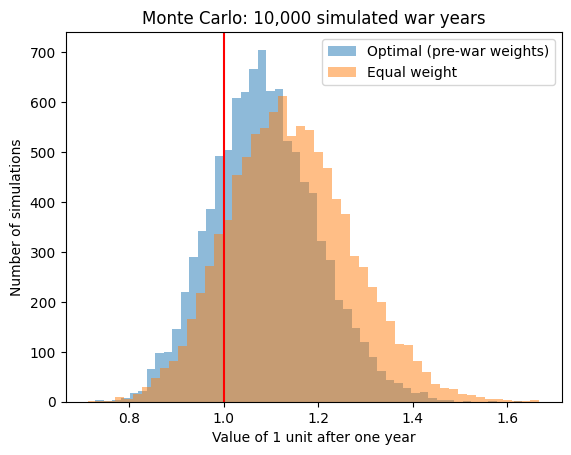

In [53]:
import matplotlib.pyplot as plt

plt.hist(optimal_results, bins=50, alpha=0.5, label="Optimal (pre-war weights)")
plt.hist(equal_results, bins=50, alpha=0.5, label="Equal weight")
plt.axvline(1, color="red")
plt.title("Monte Carlo: 10,000 simulated war years")
plt.xlabel("Value of 1 unit after one year")
plt.ylabel("Number of simulations")
plt.legend()
plt.show()